# Primary Productivity Linear Trends Analysis  
## Linear Trends Analysis of the Interim and Legacy Products
> History | Updated Feb 2025

## Overview

In this notebook, users will visualize linear trends and p-values for primary productivity. The trend analysis follows methods outlined in Melin et al 2017, see the section 2.3 "Trend estimates and comparison of trends". Users will be able to customize the notebook for their needs by selecting a region of interest using either a Longhurst Province or a custom bounding box.

We are identifying the trends during the timeseries for each sensor to track the agreement in netPP values between the legacy product, MODIS-AQUA, and interim products, VIIRS-SNPP and VIIRS-NOAA20 to provide validation that the interim netPP products can be reliably used for continuity in long-term productivity analyses.

For **MODIS-AQUA**, the result will be a **120-month (10-year)** timeseries of trend coefficients and p-values within your area of interest.

For **VIIRS-SNPP**, the result will be a **120-month (10-year)** timeseries of trend coefficients and p-values within your area of interest.

For **VIIRS-NOAA20**, the result will be a **60-month (5-year)** timeseries of trend coefficients and p-values within your area of interest.

## Datasets Overview

We calculated the pixel-by-pixel trend coefficients and p-values for the globe for each monthy at a 9km resolution across three datasets:

1. **Trend Coefficients and P-values for Monthly Primary Productivity, MODIS-AQUA, Science Quality, Global, 9km, 2013-2022**
- Distributed via the West Coast Node ERDDAP dataset at the following link:
> http://localhost:8080/erddap/griddap/trends_modis_monthly_9km.graph

2. **Trend Coefficients and P-values for Monthly Primary Productivity, VIIRS-SNPP, Science Quality, Global, 9km, 2013-2022**
- Distributed via the West Coast Node ERDDAP dataset at the following link:
> http://localhost:8080/erddap/griddap/trends_snpp_monthly_9km.graph

3. **Trend Coefficients and P-values for Monthly Primary Productivity, VIIRS-NOAA20, Science Quality, Global, 9km, 2018-2022**
- Distributed via the West Coast Node ERDDAP dataset at the following link:
> http://localhost:8080/erddap/griddap/trends_noaa20_monthly_9km.graph

## Steps:    
1. Download an area of trend coefficients from the ERDDAP server for the timeseries.

2. Mask the timeseries so that only data within a shapefile is retained.

3. Visualize the spatial variability in the timeseries trend coefficients and p-values.

4. Save the image.

## Tutorial for this notebook

The **VIIRS-NOAA20** dataset will be used in this notebook to generate a linear trends analysis over a five year period. We will access the data using the xr_open_ds() function below. The function requires:  
* The url of the ERDDAP server being use, in this case: https://coastwatch.pfeg.noaa.gov/wcn/erddap/

* The ID of the dataset, in this case is "trends_noaa20_monthly_9km".

**To use the other sensors instead,** set 'sensor = "snpp"' or 'sensor = "modis"' in the code below.


In [1]:
# define sensor (either "snpp" or "noaa20" or "modis")
sensor = "noaa20"

# check that sensor is either snpp or noaa20
if sensor not in {"snpp", "noaa20", "modis"}:
    print(
        "The variable sensor must have the value 'snpp' or 'noaa20' or 'modis'."
    )

# define time series based on sensor
if sensor == "noaa20":
    time_series = "2018-2022"
elif sensor == "snpp":
    time_series = "2013-2022"
elif sensor == "modis":
    time_series = "2013-2022"
else:
    times_series = "Unknown time series"

# set the url of the ERDDAP server
erddap_url = "http://localhost:8080/erddap"

# set the dataset ID
erddap_id = f"trends_{sensor}_monthly_9km"

print(f"Dataset ID: {erddap_id}")

Dataset ID: trends_noaa20_monthly_9km


## Shapefiles

#### Longhurst Marine Provinces  
The dataset represents the division of the world oceans into provinces as defined by Longhurst (1995; 1998; 2006). This division has been based on the prevailing role of physical forcing as a regulator of phytoplankton distribution. The Longhurst Marine Provinces dataset is available online (https://www.marineregions.org/downloads.php) and within the shapes folder associated with this repository.  

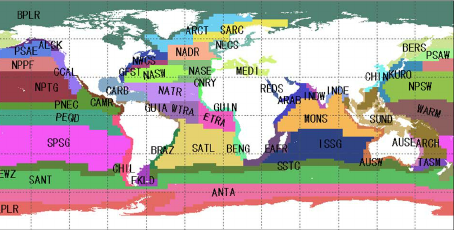

__For our example we will use the shapefile for the  "California Upwelling Coastal Province" (ProvCode: CCAL) within the Longhurst Marine Provinces classification__. 

## Resource requirements
-   **Jupyter Notebook** 

-   **Python 3** with the modules included within the *Import packages* section below

-   **Shapefile** of your area of interest
    - If you don't have shapefile, we will include some workarounds in the notebook.  
    
-   **Internet connection**  

## Import Packages

In [2]:
import matplotlib.pyplot as plt
import xarray as xr
import geopandas
import regionmask
import numpy as np
import warnings
import os

warnings.filterwarnings("ignore")

## Create a few useful functions
### Function to make an Xarray dataset connection to an ERDDAP dataset

In [ ]:
def xr_open_ds(
    e_id, e_source="https://coastwatch.pfeg.noaa.gov/wcn/erddap", dap="griddap"
):
    """
    Open a remote ERDDAP dataset as an Xarray dataset.

    Constructs the ERDDAP dataset URL using the provided dataset ID ('e_id'),
    server URL ('e_source'), and data access protocol ('dap'). Then it uses Xarray
    to open the dataset from the remote source.

    Args:
        e_id (str): ERDDAP dataset ID.
        e_source (str, optional): URL to ERDDAP server. Defaults to 'https://coastwatch.pfeg.noaa.gov/'.
            You can change it to any ERDDAP server.
        dap (str, optional): The data access protocol type. Defaults to 'griddap' which is used for
        accessing gridded datasets.

    Returns:
        array: Xarray dataset object
    """
    # remove any trailing /
    e_source = e_source.rstrip("/")

    erddap_url = "/".join([e_source, dap, e_id])

    return xr.open_dataset(erddap_url)

### Function to spatially subset an Xarray dataset using latitude and longitude

In [4]:
def subset_ds(full_ds, bnds_dic):
    """Make a spatial subset a satellite dataset.

    Args:
        full_ds (array): 2D or 3D array with lat and lon coordinate variables
        var_name (str): Name of varaible to subset.
        bnds_dic (dic): Dictionary holding lat and lon max and min values

    Returns:
        array: Xarray dataset object
    """
    # correct for reversed latitude order on a dataset
    if full_ds.latitude[0] > full_ds.latitude[-1]:
        lt_first = bnds_dic["lat_max"]
        lt_last = bnds_dic["lat_min"]
    else:
        lt_first = bnds_dic["lat_min"]
        lt_last = bnds_dic["lat_max"]

    # subset the dataset
    return full_ds.sel(
        latitude=slice(lt_first, lt_last),
        longitude=slice(bnds_dic["lon_min"], bnds_dic["lon_max"]),
    )

## Load the Longhurst Provinces shapefiles into a geopandas dataframe
In this example, we'll use the shapefile for the  **California Upwelling Coastal Province** (ProvCode: CCAL) from the Longhurst Marine Provinces classification.

- This step also isolates the California Upwelling Coastal Province.

- To inspect the shapefile's position within the dataframe, uncomment the line: 'print(shapefiles[40:45])'

In [5]:
# create path to shapefile dataset
shape_path = os.path.join(
    "/Users/madisonrichardson/netpp/resources/Longhurst/Longhurst_world_v4_2010.shp"
)

# create a dataframe
shapefiles = geopandas.read_file(shape_path)

# uncomment net line to see the California Upwelling Coastal Province entry
# print(shapefiles[40:45])

# Display the available ProvCodes
available_provcodes = shapefiles["ProvCode"].unique()
print("Available ProvCodes:")
col_width = 5
for i in range(0, len(available_provcodes), col_width):
    print(" | ".join(available_provcodes[i : i + col_width]))

# Select region of interest
ProvCode = "CCAL"

# Locate the row with the ProvCode code
prov_wnt = shapefiles.loc[shapefiles["ProvCode"] == ProvCode]
prov_wnt
print(prov_wnt)

# Check if the selected ProvCode exists
if prov_wnt.empty:
    raise ValueError(
        f"Invalid ProvCode '{ProvCode}'. Please select one from the list above."
    )

Available ProvCodes:
BPLR | ARCT | SARC | NADR | GFST
NASW | NATR | WTRA | ETRA | SATL
NECS | CNRY | GUIN | GUIA | NWCS
MEDI | CARB | NASE | BRAZ | FKLD
BENG | MONS | ISSG | EAFR | REDS
ARAB | INDE | INDW | AUSW | BERS
PSAE | PSAW | KURO | NPPF | NPSW
TASM | SPSG | NPTG | PNEC | PEQD
WARM | ARCH | ALSK | CCAL | CAMR
CHIL | CHIN | SUND | AUSE | NEWZ
SSTC | SANT | ANTA | APLR
   ProvCode                                        ProvDescr  \
43     CCAL  Coastal - California Upwelling Coastal Province   

                                             geometry  
43  MULTIPOLYGON (((-110.5 24.5, -110.5 24.22013, ...  


## Create the regional mask for the California Upwelling Coastal Province
Display the region after creating it. 

<GeoAxes: >

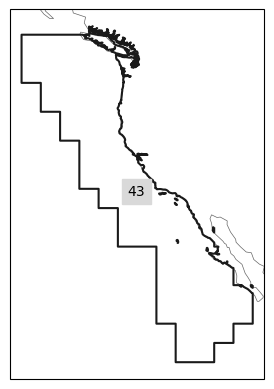

In [6]:
region = regionmask.from_geopandas(prov_wnt)
region.plot()

## Find the coordinates of the bounding box
* The bounding box is the smallest rectangle that will completely enclose the province.

* We will use the bounding box coordinates to subset the satellite data. 

In [7]:
gs_bnds = prov_wnt.bounds
gs_bnds

,minx,miny,maxx,maxy
43,-134.5,16.5,-110.5,51.383431


### To make it easier to use the subset_ds() function without a shapefile, put the bounding box coordinates in a Python dictionary.

In [8]:
geo_bnds = {}
geo_bnds["lon_min"] = gs_bnds.minx.item()
geo_bnds["lon_max"] = gs_bnds.maxx.item()
geo_bnds["lat_min"] = gs_bnds.miny.item()
geo_bnds["lat_max"] = gs_bnds.maxy.item()

## Open the dataset into a Xarray dataset object
Pass the dataset ID and the ERDDAP server location to the xr_open_ds() function. 

* For details on xr_open_ds(), refer to the function's document string.

* **Reminder**: The erddap_id and erddap_url variables were set above.

In [9]:
ds = xr_open_ds(erddap_id, e_source=erddap_url)

ds

<xarray.Dataset> Size: 112MB
Dimensions:    (time: 1, latitude: 2160, longitude: 4320)
Coordinates:
  * time       (time) datetime64[ns] 8B 2018-01-16T12:00:00
  * latitude   (latitude) float32 9kB 89.96 89.88 89.79 ... -89.79 -89.88 -89.96
  * longitude  (longitude) float32 17kB -180.0 -179.9 -179.8 ... 179.9 180.0
Data variables:
    beta       (time, latitude, longitude) float32 37MB ...
    pval       (time, latitude, longitude) float32 37MB ...
    n          (time, latitude, longitude) float32 37MB ...
Attributes: (12/46)
    acknowledgement:           The project was supported by funding from the ...
    cdm_data_type:             Grid
    contributor:               Dale Robinson, Isaac Schroeder, Madison Richar...
    contributor_role:          project management/development, production
    contributors:              Dale Robinson, Isaac Shroeder, Ryan Vandermeul...
    Conventions:               CF-1.10, COARDS, ACDD-1.3
    ...                        ...
    summary:                   Trends between primary productivity or Photosy...
    time_coverage_end:         2018-01-16T12:00:00Z
    time_coverage_resolution:  PD1
    time_coverage_start:       2018-01-16T12:00:00Z
    title:                     Trend coefficients and p values for monthly pr...
    Westernmost_Easting:       -179.9583

## Subset the satellite data
* Pass the geo_bnds variable containing bounding box coordinates to the subset_ds() function.  

__The result will be a dataset that is:__  
* Spatially subsetted to the dimensions of the bounding box corresponding to the specified sensor (either SNPP, MODIS, or NOAA20).

In [10]:
subsetted_ds = subset_ds(ds, geo_bnds)

## Determine the approximate download size

Before downloading the data, it's helpful to estimate the size of your data request to ERDDAP. 
* The data still has not been downloaded. That will happen later when an operation that needs the data is initiated. 

Depending on the installation, ERDDAP has maximum single download **limit of 2 Gigabytes**.  
* That seems large, but with satellite dataset large data volume adds up quickly.

The calculation for data download size estimate is below. 
* If the download size is nearing the single download limit, try splitting your download request into 2 or several separate requests and concatenate the data from the separate request.  

#### The request in this example is around 0.70 MB, well within the single download limit.

In [11]:
# get the number of longitude pixels along the longitude axis in the subsetted dataset
pixel_lon_axis = subsetted_ds.longitude.shape[0]

# get the number of latitude pixels along the latitude axis in the subsetted dataset
pixel_lon_axis = subsetted_ds.latitude.shape[0]

# set the memory size for a float data type in bytes
float_memory_size = 4

# get the number of timesteps in the subsetted dataset
no_of_timesteps = subsetted_ds.time.shape[0]

# calculate the approximate download size
download_size = (
    pixel_lon_axis * pixel_lon_axis * float_memory_size * no_of_timesteps
)

print("download_size", int(download_size) / 1000000, "Mb")

download_size 0.702244 Mb


## Create a mask and apply it to the data
__The result will be datasets that are:__  
* Masked to retain only the data within the shapefile. 

In [12]:
# create the mask
mask = region.mask(subsetted_ds.longitude, subsetted_ds.latitude)

# apply mask the the satellite data
trends_ds = subsetted_ds.where(mask == region.numbers[0])

# set workaround flag
wa_flag = False

## Workaround if you do not have a shapefile

If you don't have a shapefile, you can instead select a rectangular area define by a latitude and a longitude range that encompasses your area of interest.  

#### Please see [Appendix B: Steps for use without a shapefile](#no_shapefile) below.

## Visualize the spatial variability of the trend coefficients and p-values for VIIRS-NOAA20

Plot the spatial variability of the trend coefficients for the selected Longhurst Province.
* Uncomment the last line to save the graph.

#### **Results for VIIRS-NOAA20 CCAL Region using shapefile** (workaround results will be different):

#### Visualize the trends

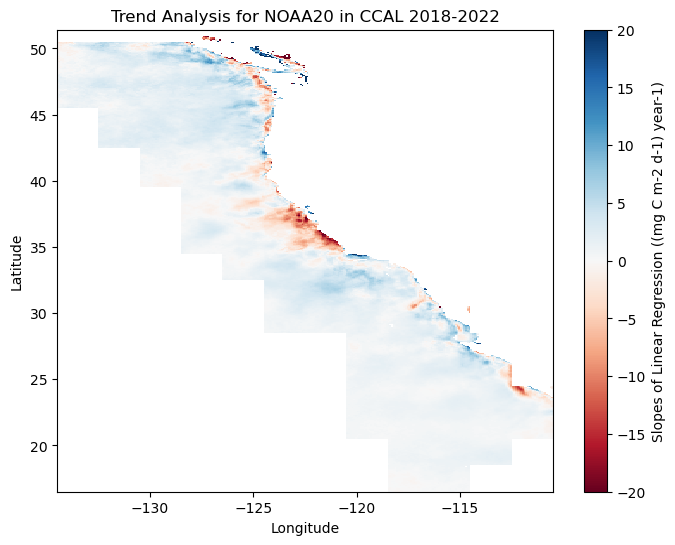

In [13]:
# Visualize the trends
slope = trends_ds.beta.squeeze()

fig, ax = plt.subplots(figsize=(8, 6))

# plot masked 5-year trends for the selected province
pc = ax.pcolormesh(
    trends_ds.longitude,
    trends_ds.latitude,
    slope,
    vmin=-20,
    vmax=20,
    cmap="RdBu",
)

# set up title, labels, and color bar
ax.set_title(
    f"Trend Analysis for {sensor.upper()} in {ProvCode} {(time_series)}"
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
fig.colorbar(
    pc, ax=ax, label="Slopes of Linear Regression ((mg C m-2 d-1) year-1)"
)

plt.show()

# uncomment the next last line to save the figure
# plt.savefig('my_trends_spatial_variability.png')

#### Visualize the p-values

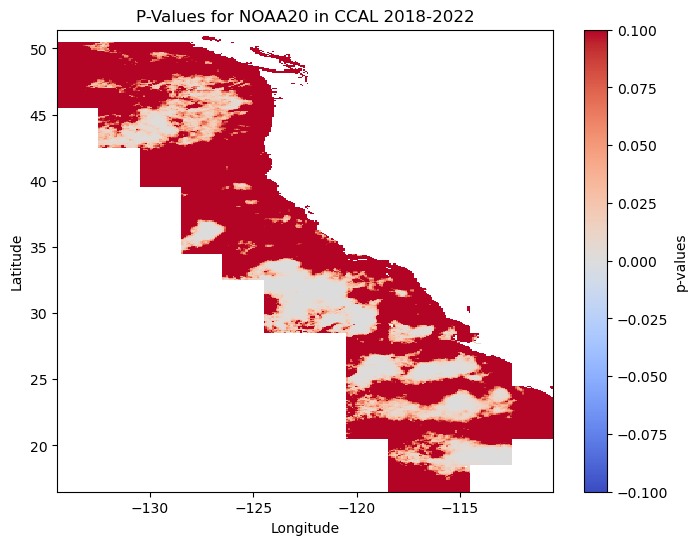

In [14]:
# Visualize the p-values
p_value = trends_ds.pval.squeeze()

fig, ax = plt.subplots(figsize=(8, 6))

# plot masked 5-year p-values for the selected province
pc = ax.pcolormesh(
    trends_ds.longitude,
    trends_ds.latitude,
    p_value,
    vmin=-0.1,
    vmax=0.1,
    cmap="coolwarm",
)


# set up title, labels, and color bar
ax.set_title(f"P-Values for {sensor.upper()} in {ProvCode} {(time_series)}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
fig.colorbar(pc, ax=ax, label="p-values")

plt.show()

# uncomment the next last line to save the figure
# plt.savefig('my_pvalues_spatial_variability.png')

## Appendix A: Visualize the unmasked and masked data on a map
The maps shows the full coverage of the bounding box and the masked area set by the shapefile for CCAL.

#### Visualize the unmasked and masked trends

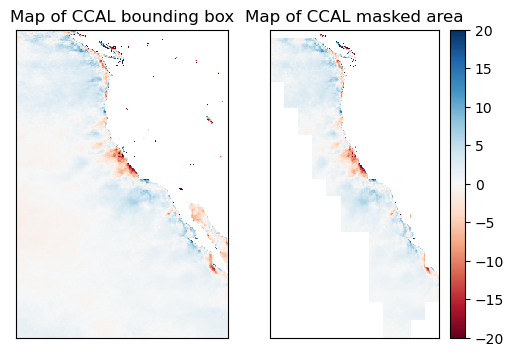

In [15]:
# if wa_flag is True, set 'plot_ds' to 'trends_ds', if not use 'subsetted_ds'
if wa_flag:
    plot_ds = trends_ds
else:
    plot_ds = subsetted_ds

# create the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 4))

# customize the first subplot (ax1)
ax1.set_title("Map of CCAL bounding box")
ax1.set_yticks([])
ax1.set_xticks([])

# plot data on ax1 where plot_ds = subsetted_ds and reverse latitude order for correct orientation
ax1.pcolormesh(
    plot_ds["beta"]
    .isel(time=0)
    .reindex(latitude=list(reversed(plot_ds.latitude))),
    vmin=-20,
    vmax=20,
    cmap="RdBu",
)

# customize the second subplot (ax2)
ax2.set_title("Map of CCAL masked area")
ax2.set_yticks([])
ax2.set_xticks([])

# plot data on ax2 where plot_ds = trends_ds and reverse latitude order for correct orientation
pc = ax2.pcolormesh(
    trends_ds["beta"]
    .isel(time=0)
    .reindex(latitude=list(reversed(trends_ds.latitude))),
    vmin=-20,
    vmax=20,
    cmap="RdBu",
)

# add a color bar to the figure
fig.colorbar(pc)

#### Visualize the unmasked and masked p-values

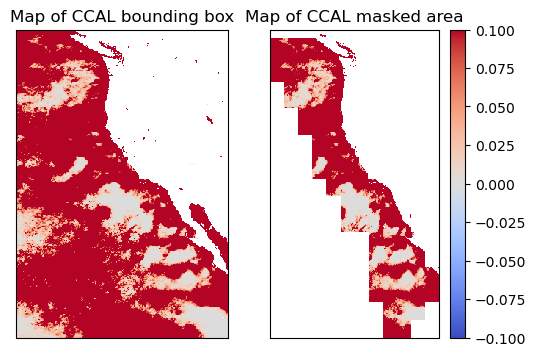

In [16]:
# if wa_flag is True, set 'plot_ds' to 'trends_ds', if not use 'subsetted_ds'
if wa_flag:
    plot_ds = trends_ds
else:
    plot_ds = subsetted_ds

# create the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 4))

# customize the first subplot (ax1)
ax1.set_title("Map of CCAL bounding box")
ax1.set_yticks([])
ax1.set_xticks([])

# plot data on ax1 where plot_ds = subsetted_ds and reverse latitude order for correct orientation
ax1.pcolormesh(
    plot_ds["pval"]
    .isel(time=0)
    .reindex(latitude=list(reversed(plot_ds.latitude))),
    vmin=-0.1,
    vmax=0.1,
    cmap="coolwarm",
)

# customize the second subplot (ax2)
ax2.set_title("Map of CCAL masked area")
ax2.set_yticks([])
ax2.set_xticks([])

# plot data on ax2 where plot_ds = trends_ds and reverse latitude order for correct orientation
pc = ax2.pcolormesh(
    trends_ds["pval"]
    .isel(time=0)
    .reindex(latitude=list(reversed(trends_ds.latitude))),
    vmin=-0.1,
    vmax=0.1,
    cmap="coolwarm",
)

# add a color bar to the figure
fig.colorbar(pc)

## Appendix B: Steps for use without a shapefile
<a id='no_shapefile'></a>
### __Do not run this code if you have used a shapefile above!__
Use this method in place of cells tagged "Shapefile method".  

If you don't have a shapefile, you can just select a rectangular area that encompasses your area of interest. The area is define by a the maximum and minimum values of a latitude and a longitude range.   

__Steps__:  
1. Load the geo_bnds dictionary with the minimum and maximum values for latitude and longitude the area of interest. 
* An area off the Oregon coast is used the example below:

    * Latitude range: 42.0&deg; to 46.0&deg; N

    * Longitude range: -128.0&deg; to -124&deg; E
2. Proceed through the data download and subsetting steps as listed below:

* Note that the masking steps have been omitted.

In [17]:
geo_bnds = {}
geo_bnds["lon_min"] = -128.0
geo_bnds["lon_max"] = -124.0
geo_bnds["lat_min"] = 42.0
geo_bnds["lat_max"] = 46.0

# Change this code "subsetted_ds = subset_ds(ds, erddap_var, geo_bnds)" to:
trends_ds = subset_ds(ds, geo_bnds)

# set workaround flag
wa_flag = True

# Omit create the mask
# mask = region.mask(subsetted_ds.longitude, subsetted_ds.latitude)

# Omit apply mask the the satellite data
# trends_ds = subsetted_ds.where(mask == region.numbers[0])